# Data Cleanser Project

### Part A : Handling Missing Values

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math
import sqlite3

In [38]:
df = pd.read_csv("Dataset/Patient_Health_Records.csv")
df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,60.0,Male,North,30.6,107.1,156.7,81.3,1
1,2,67.0,Male,West,18.5,96.6,167.9,136.2,0
2,3,55.0,Male,West,21.7,131.2,237.1,70.7,0
3,4,71.0,Male,West,23.8,100.9,254.9,107.0,1
4,5,25.0,Female,North,24.1,114.1,171.7,74.8,0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      300 non-null    int64  
 1   age             283 non-null    float64
 2   gender          285 non-null    object 
 3   region          287 non-null    object 
 4   bmi             277 non-null    float64
 5   blood_pressure  300 non-null    float64
 6   cholesterol     290 non-null    float64
 7   glucose         291 non-null    float64
 8   disease_risk    300 non-null    int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 21.2+ KB


In [40]:
df.describe()

,patient_id,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,300.000000,283.000000,277.000000,300.000000,290.000000,291.000000,300.000000
mean,150.500000,50.530035,27.401444,126.691333,203.276897,131.915808,0.310000
std,86.746758,17.773845,6.618469,26.527064,44.166566,48.657203,0.463266
min,1.000000,20.000000,18.100000,90.000000,140.200000,70.100000,0.000000
25%,75.750000,34.500000,22.300000,107.450000,174.175000,101.400000,0.000000
50%,150.500000,52.000000,26.800000,124.050000,198.250000,127.800000,0.000000
75%,225.250000,66.000000,31.800000,141.375000,227.375000,155.000000,1.000000
max,300.000000,80.000000,52.500000,245.000000,410.000000,390.000000,1.000000


##### 1. Identify Missing Values and provide a summary report (percentage per column)

In [41]:
print((df.isnull().sum()/len(df))*100)
print(df.isnull().sum())

patient_id        0.000000
age               5.666667
gender            5.000000
region            4.333333
bmi               7.666667
blood_pressure    0.000000
cholesterol       3.333333
glucose           3.000000
disease_risk      0.000000
dtype: float64
patient_id         0
age               17
gender            15
region            13
bmi               23
blood_pressure     0
cholesterol       10
glucose            9
disease_risk       0
dtype: int64


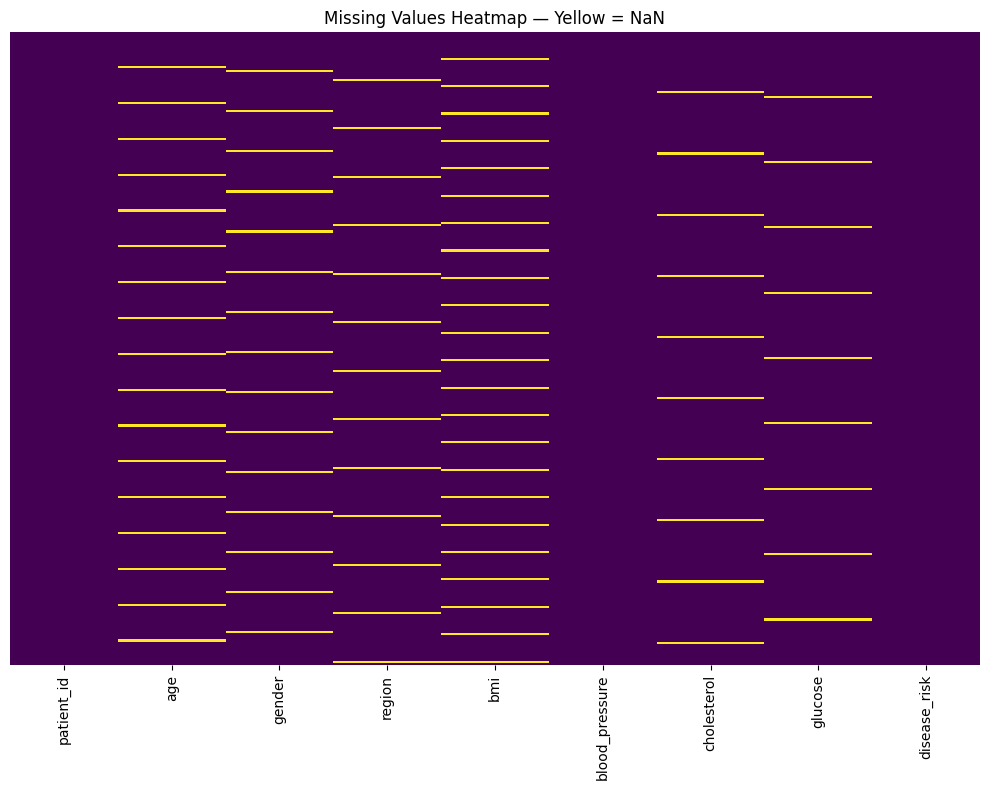

In [42]:
# ─── Heatmap of missing values ───
plt.figure(figsize=(10, 8))
sns.heatmap(df.isnull(), yticklabels=False,
            cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap — Yellow = NaN')
plt.tight_layout()
plt.show()

##### 2. Apply the following imputation techniques and compare results :

- Simple Imputer (Numerical): Replace missing BMI with mean or median 

In [43]:
from sklearn.impute import SimpleImputer

print("Before Mean Imputation:", df["bmi"].isnull().sum())

mean_imputer = SimpleImputer(strategy="mean")

df["bmi"] = mean_imputer.fit_transform(df[["bmi"]])


print("After Mean Imputation:")
print(df["bmi"].isnull().sum())

Before Mean Imputation: 23
After Mean Imputation:
0


- Simple Imputer (Categorical): Replace missing Region with the most frequent value 

In [44]:
print("Before Most Frequent Imputation: ", df["region"].isnull().sum())

most_frequent_imputation = SimpleImputer(strategy="most_frequent")

df["region"] = most_frequent_imputation.fit_transform(df[["region"]]).flatten()

# We've used .flatten() here to convert the 2D array returned by fit_transform() into a 1D array 
# so it can be assigned to a single DataFrame column (df["region"]).

# We can also use .ravel() instead of .flatten().

print("After Mean Imputation: ", df["region"].isnull().sum())

Before Most Frequent Imputation:  13
After Mean Imputation:  0


- Most Frequent Imputation: Replace missing Gender with the most common category

In [45]:
print("Before Most Frequent Imputation: ", df["gender"].isnull().sum())

most_frequent_gender = SimpleImputer(strategy="most_frequent")

df["gender"] = most_frequent_gender.fit_transform(df[["gender"]]).flatten()

print("After Most Frequent Imputation (Gender): ", df["gender"].isnull().sum())

Before Most Frequent Imputation:  15
After Most Frequent Imputation (Gender):  0


- Missing Indicator + Random Sample Imputation : Create binary indicator columns for missingness and use random sampling to impute values. 

In [46]:
# ---------- Missing Indicator using sklearn ----------


from sklearn.impute import MissingIndicator

numeric_cols = df[["age", "bmi", "cholesterol", "glucose"]]

indicator = MissingIndicator(features="missing-only")

indicator_array  = indicator.fit_transform(numeric_cols)

indicator_cols = [numeric_cols.columns[i] + "_missing"
                  for i in indicator.features_]

df_indicator = pd.DataFrame(
    indicator_array.astype(int),
    columns=indicator_cols,
    index=df.index
)

# --- Mean Imputation --- 
imputer = SimpleImputer(strategy="mean")

df_imputed = pd.DataFrame(
    imputer.fit_transform(numeric_cols),
    columns=numeric_cols.columns,
    index=df.index
)

# --- Merge Imputed Data + Indicator --- 
df_final = pd.concat([df_imputed, df_indicator], axis=1)

print("Final Dataset with Indicators:")
print(df_final.round(2))

print("\nMissing column indices:", indicator.features_)
print("Missing columns:", list(numeric_cols.columns[indicator.features_]))

Final Dataset with Indicators:
      age   bmi  cholesterol  glucose  age_missing  cholesterol_missing  \
0    60.0  30.6        156.7     81.3            0                    0   
1    67.0  18.5        167.9    136.2            0                    0   
2    55.0  21.7        237.1     70.7            0                    0   
3    71.0  23.8        254.9    107.0            0                    0   
4    25.0  24.1        171.7     74.8            0                    0   
..    ...   ...          ...      ...          ...                  ...   
295  52.0  52.5        193.0    144.8            0                    0   
296  65.0  33.3        146.7     84.5            0                    0   
297  46.0  27.5        177.0     72.4            0                    0   
298  36.0  27.4        181.3     77.0            0                    0   
299  23.0  18.5        232.3    154.2            0                    0   

     glucose_missing  
0                  0  
1                  0  

In [47]:
# ---------- Random Sample Imputation ----------

print("Missing Values: ", df.isnull().sum())

df_copy = df.copy()

np.random.seed(42)

if df_copy["age"].isnull().sum() > 0:
    null_count = df_copy["age"].isnull().sum()
    random_values = df["age"].dropna().sample(
        n=null_count,
        replace=True,
        random_state=42
    ).values
    df_copy.loc[df_copy["age"].isnull(), "age"] = random_values
    
    
print("age - \nOriginal Non-Null States: ")
print(df["age"].dropna().describe().round(1))

print("\nage - After Imputation Stats:")
print(df_copy["age"].dropna().describe().round(1))

Missing Values:  patient_id         0
age               17
gender             0
region             0
bmi                0
blood_pressure     0
cholesterol       10
glucose            9
disease_risk       0
dtype: int64
age - 
Original Non-Null States: 
count    283.0
mean      50.5
std       17.8
min       20.0
25%       34.5
50%       52.0
75%       66.0
max       80.0
Name: age, dtype: float64

age - After Imputation Stats:
count    300.0
mean      50.5
std       17.8
min       20.0
25%       35.0
50%       52.0
75%       66.0
max       80.0
Name: age, dtype: float64


- KNN Imputer : Apply k-Nearest Neighbors imputation for Multivariate imputation

In [83]:
from sklearn.impute import KNNImputer

num_cols = ["age","bmi","cholesterol","glucose"]

print("Before KNN Imputation:")
print(df[num_cols].isnull().sum())

df_knn = df.copy()

knn_imputer = KNNImputer(n_neighbors=5)

df_knn[num_cols] = knn_imputer.fit_transform(df[num_cols])

print("\nAfter KNN Imputation:")
print(df_knn[num_cols].isnull().sum())

Before KNN Imputation:
age            17
bmi             0
cholesterol    10
glucose         9
dtype: int64

After KNN Imputation:
age            0
bmi            0
cholesterol    0
glucose        0
dtype: int64


- MICE Algorithm : Perform chained equations imputation for multiple vairables simultaneously

In [49]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

print(f"Total Missing Values: {df[num_cols].isnull().sum().sum()}")

mice_imputer = IterativeImputer(max_iter=10, random_state=42)

mice_imputed = pd.DataFrame(
        mice_imputer.fit_transform(df[num_cols]),
        columns=df[num_cols].columns
)


print("After MICE Imputation : ")
print(mice_imputed.round(2))

print("Total missing values after: ", mice_imputed.isnull().sum().sum())

Total Missing Values: 36
After MICE Imputation : 
      age   bmi  cholesterol  glucose
0    60.0  30.6        156.7     81.3
1    67.0  18.5        167.9    136.2
2    55.0  21.7        237.1     70.7
3    71.0  23.8        254.9    107.0
4    25.0  24.1        171.7     74.8
..    ...   ...          ...      ...
295  52.0  52.5        193.0    144.8
296  65.0  33.3        146.7     84.5
297  46.0  27.5        177.0     72.4
298  36.0  27.4        181.3     77.0
299  23.0  18.5        232.3    154.2

[300 rows x 4 columns]
Total missing values after:  0


### Part B : Handling Outliers

##### 3. Detect and remove outliers using:

- Z-Score Method : Identify patients with extreme cholesterol or glucose values

In [50]:
# ----------- Calculating Z-Score -----------

cholesterol_mean = df["cholesterol"].mean()
cholesterol_std = df["cholesterol"].std()

glucose_mean = df["glucose"].mean()
glucose_std = df["glucose"].std()

print("Mean (cholesterol): ",cholesterol_mean)
print("Standard Deviation (cholesterol): ",cholesterol_std)

print("Mean (glucose): ",glucose_mean)
print("Standard Deviation (glucose): ",glucose_std)

# Calculating Z-Score for each raw of Cholesterol's column
df["Z-Score (C)"] = (df["cholesterol"] - cholesterol_mean)/cholesterol_std
# Calculating Z-Score for each raw of Glucose's column
df["Z-Score (G)"] = (df["glucose"] - glucose_mean)/glucose_std

Mean (cholesterol):  203.27689655172412
Standard Deviation (cholesterol):  44.16656641568596
Mean (glucose):  131.91580756013747
Standard Deviation (glucose):  48.65720300666495


In [51]:
# ----------- Identifying Outliers -----------
threshold = 3
outliers_C = df[df["Z-Score (C)"].abs() > 3]
outliers_G = df[df["Z-Score (G)"].abs() > 3]

print(f"Outliers Detected > {threshold}:")
print(outliers_C[["patient_id","cholesterol","Z-Score (C)"]])
print(outliers_G[["patient_id","glucose","Z-Score (G)"]])

Outliers Detected > 3:
     patient_id  cholesterol  Z-Score (C)
42           43        410.0     4.680534
85           86        410.0     4.680534
128         129        410.0     4.680534
171         172        410.0     4.680534
214         215        410.0     4.680534
257         258        410.0     4.680534
     patient_id  glucose  Z-Score (G)
46           47    390.0     5.304131
93           94    390.0     5.304131
140         141    390.0     5.304131
187         188    390.0     5.304131
234         235    390.0     5.304131
281         282    390.0     5.304131


In [52]:
# ----------- Removing Outliers -----------

df_clean_C = df[df["Z-Score (C)"].abs() <= threshold].copy()
df_clean_C = df_clean_C.drop(columns=["Z-Score (C)"]) 

df_clean_G = df[df["Z-Score (G)"].abs() <= threshold].copy()
df_clean_G = df_clean_G.drop(columns=["Z-Score (G)"]) 

print("Total Rows Before Cleaning: ", len(df))
print("\nRows After Cleaning Outliers (From 'cholesterol'): ", len(df_clean_C))
print("\nRows After Cleaning Outliers (From 'glucose'): ", len(df_clean_G))
print(f"Outliers removed:     {len(df) - len(df_clean_C)}")

print("\nMean Cholesterol Before: ", round(df["cholesterol"].mean(), 1))
print("Mean Cholesterol After: ", round(df_clean_C["cholesterol"].mean(), 1))
print(f"Outliers removed:     {len(df) - len(df_clean_G)}")


print("\nMean Glucose Before: ", round(df["glucose"].mean(), 1))
print("Mean Glucose After: ", round(df_clean_G["glucose"].mean(), 1))

Total Rows Before Cleaning:  300

Rows After Cleaning Outliers (From 'cholesterol'):  284

Rows After Cleaning Outliers (From 'glucose'):  285
Outliers removed:     16

Mean Cholesterol Before:  203.3
Mean Cholesterol After:  198.9
Outliers removed:     15

Mean Glucose Before:  131.9
Mean Glucose After:  126.5


- IQR Method : Use inquartile range to detect unusual BMI values

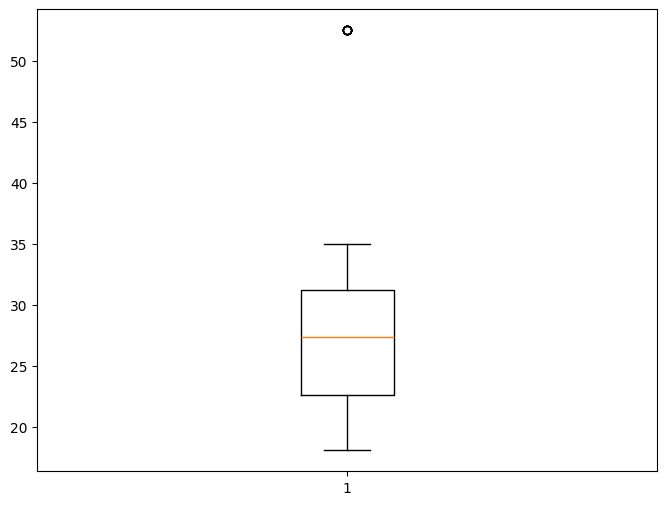

In [53]:
plt.figure(figsize=(8,6))

plt.boxplot(data=df, x="bmi")

plt.show()

In [54]:
# ----------- Calculating Q1 & Q3 -----------

Q1 = df["bmi"].quantile(0.25)       # Q1
Q3 = df["bmi"].quantile(0.75)       # Q3
IQR = Q3 - Q1

print(f"Q1 (25th Percentile): {Q1}")
print(f"Q3 (75th Percentile): {Q3}")
print(f"IQR (Q3 - Q1): {IQR}")

Q1 (25th Percentile): 22.6
Q3 (75th Percentile): 31.225
IQR (Q3 - Q1): 8.625


In [55]:
# ----------- Calculating Fenses (Upper & Lower) -----------

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"Lower Fence : {lower_fence} (Outliers below this)")
print(f"Upper Fence : {upper_fence} (Outliers above this)")

Lower Fence : 9.662500000000001 (Outliers below this)
Upper Fence : 44.1625 (Outliers above this)


In [56]:
# ----------- Identifying Outliers -----------

outlier_mask = (df["bmi"] < lower_fence) | (df["bmi"] > upper_fence)
print(f"\nOutliers in {"bmi"} :")
print(df[outlier_mask][["patient_id", "bmi"]])

data_mask = (df["bmi"] > lower_fence) & (df["bmi"] < upper_fence)
print(f"\nGenuine Data in {"bmi"} :")
print(df[data_mask][["patient_id", "bmi"]])


Outliers in bmi :
     patient_id   bmi
36           37  52.5
73           74  52.5
110         111  52.5
147         148  52.5
184         185  52.5
221         222  52.5
258         259  52.5
295         296  52.5

Genuine Data in bmi :
     patient_id        bmi
0             1  30.600000
1             2  18.500000
2             3  21.700000
3             4  23.800000
4             5  24.100000
..          ...        ...
294         295  19.300000
296         297  33.300000
297         298  27.500000
298         299  27.401444
299         300  18.500000

[292 rows x 2 columns]


In [57]:
# ----------- Rremoving Outliers -----------
df_clean_iqr = df[~outlier_mask].copy()

print(f"Rows Before: {len(df)} | Rows After: {len(df_clean_iqr)}")
print(f"Outliers Removed: {outlier_mask.sum()}")
print(f"\nMean 'bmi' before: {df["bmi"].mean():.1f}")
print(f"Mean 'bmi' after: {df_clean_iqr["bmi"].mean():.1f}")

Rows Before: 300 | Rows After: 292
Outliers Removed: 8

Mean 'bmi' before: 27.4
Mean 'bmi' after: 26.7


In [58]:
df_clean_iqr

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,Z-Score (C),Z-Score (G)
0,1,60.0,Male,North,30.600000,107.1,156.7,81.3,1,-1.054574,-1.040253
1,2,67.0,Male,West,18.500000,96.6,167.9,136.2,0,-0.800988,0.088048
2,3,55.0,Male,West,21.700000,131.2,237.1,70.7,0,0.765808,-1.258104
3,4,71.0,Male,West,23.800000,100.9,254.9,107.0,1,1.168828,-0.512068
4,5,25.0,Female,North,24.100000,114.1,171.7,74.8,0,-0.714950,-1.173841
...,...,...,...,...,...,...,...,...,...,...,...
294,295,53.0,Female,East,19.300000,129.5,147.4,130.2,0,-1.265140,-0.035263
296,297,65.0,Female,North,33.300000,121.2,146.7,84.5,1,-1.280989,-0.974487
297,298,46.0,Female,North,27.500000,137.1,177.0,72.4,0,-0.594950,-1.223165
298,299,36.0,Male,North,27.401444,93.2,181.3,77.0,0,-0.497591,-1.128626


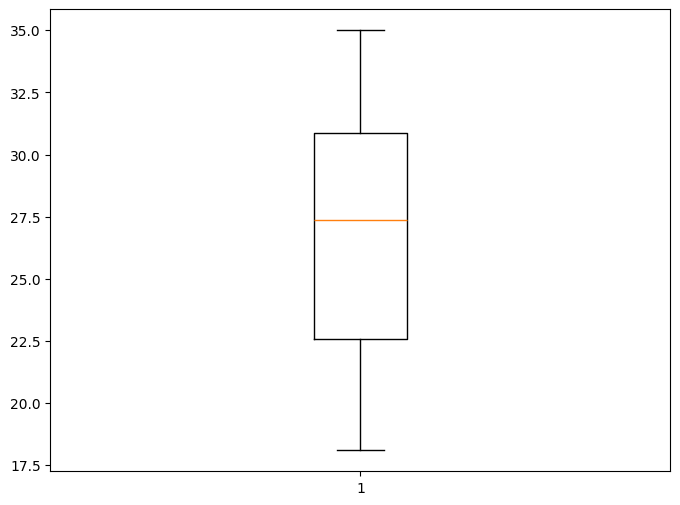

In [59]:
plt.figure(figsize=(8,6))
plt.boxplot(data=df_clean_iqr, x="bmi")
plt.show()

- Percentile Method : Cap values below 1st percentile and 99th percentile

In [60]:
lower_pct = 0.01
upper_pct = 0.99

lower_bound = df["blood_pressure"].quantile(lower_pct)
upper_bound = df["blood_pressure"].quantile(upper_pct)

print(f"\n-- Percentile Boundaries --")
print(f"1st Percentile : {lower_bound:.2f} bp")
print(f"99th Percentile : {upper_bound:.2f} bp")
print(f"Normal Range : {lower_bound} bp to {upper_bound} bp")


-- Percentile Boundaries --
1st Percentile : 90.50 bp
99th Percentile : 245.00 bp
Normal Range : 90.497 bp to 245.0 bp


In [61]:
# ----------- Identfying Outliers -----------
outlier_mask = ((df["blood_pressure"] < lower_bound) | (df["blood_pressure"] > upper_bound))

print("Outliers Detected:")
print(df[outlier_mask][["patient_id", "blood_pressure"]])
print(f"Total Outliers: {outlier_mask.sum()}")

Outliers Detected:
     patient_id  blood_pressure
16           17            90.2
60           61            90.0
217         218            90.1
Total Outliers: 3


In [62]:
# ----------- Removing Outliers -----------
df_cleaned_percentile = df[~outlier_mask].copy()

print(f"\n--- Results ---")
print(f"Rows before: {len(df)} | Rows after: {len(df_cleaned_percentile)}")
print(f"\nblood_pressure Mean BEFORE: {df['blood_pressure'].mean():.2f} bp")
print(f"blood_pressure Mean AFTER:  {df_cleaned_percentile['blood_pressure'].mean():.2f} bp")
print(f"\nblood_pressure Min BEFORE: {df['blood_pressure'].min():.2f} bp")
print(f"blood_pressure Min AFTER:  {df_cleaned_percentile['blood_pressure'].min():.2f} bp")
print(f"\nblood_pressure Max BEFORE: {df['blood_pressure'].max():.2f} bp")
print(f"blood_pressure Max AFTER:  {df_cleaned_percentile['blood_pressure'].max():.2f} bp")


# Here 245.00 is not removed because it is equal to the 99th percentile, not greater than it.


--- Results ---
Rows before: 300 | Rows after: 297

blood_pressure Mean BEFORE: 126.69 bp
blood_pressure Mean AFTER:  127.06 bp

blood_pressure Min BEFORE: 90.00 bp
blood_pressure Min AFTER:  90.50 bp

blood_pressure Max BEFORE: 245.00 bp
blood_pressure Max AFTER:  245.00 bp


In [63]:
print("Upper Bound:", upper_bound)
print("Maximum Value:", df["blood_pressure"].max())
print(df[df["blood_pressure"] >= upper_bound][["patient_id", "blood_pressure"]])

Upper Bound: 245.0
Maximum Value: 245.0
     patient_id  blood_pressure
40           41           245.0
81           82           245.0
122         123           245.0
163         164           245.0
204         205           245.0
245         246           245.0
286         287           245.0


##### 4. Apply Winsorization to cap extreme outliers instead of removing them

- Winsorizaion with pandas clip() (Simplest Method)

In [64]:
lower = df["cholesterol"].quantile(0.05)
upper = df["cholesterol"].quantile(0.95)

print(f"5th Percentile: {lower}")
print(f"95th Percentile: {upper}")

df["cholesterol_winsorized"] = df["cholesterol"].clip(lower=lower, upper=upper)

print("\nAfter Winsorization (clip):")
print(df['cholesterol_winsorized'])
print(f"\nMean before: {df['cholesterol'].mean():.1f}")
print(f"Max before:  {df['cholesterol'].max():.1f}")
print(f"\nMean after: {df['cholesterol_winsorized'].mean():.1f}")
print(f"Max after:  {df['cholesterol_winsorized'].max():.1f}")
print("\nDataset size before: ", len(df))
print("Dataset size after: ", len(df))

5th Percentile: 147.49
95th Percentile: 255.35500000000002

After Winsorization (clip):
0      156.70
1      167.90
2      237.10
3      254.90
4      171.70
        ...  
295    193.00
296    147.49
297    177.00
298    181.30
299    232.30
Name: cholesterol_winsorized, Length: 300, dtype: float64

Mean before: 203.3
Max before:  410.0

Mean after: 200.1
Max after:  255.4

Dataset size before:  300
Dataset size after:  300


- Winsorization with scipy

In [65]:
from scipy.stats.mstats import winsorize

df_winsorization = df.copy()

for col in ["bmi", "blood_pressure", "cholesterol", "glucose"]:
    df_winsorization[col] = winsorize(df_winsorization[col], limits=[0.05,0.05])
    

print("Dataset size before: ", len(df))
print("Dataset size after: ", len(df_winsorization))

Dataset size before:  300
Dataset size after:  300


##### 5. Compare dataset shape and summary before vs after outlier treatment

In [ ]:
# ----- Comparing Shapes -----

print(f"Original Dataset shape: {df.shape}")
print(f"After Z-Score (on 'cholesterol' columns): {df_clean_C.shape}")
print(f"After Z-Score (on 'glucose' column): {df_clean_G.shape}")
print(f"After IQR Method: {df_clean_iqr.shape}")
print(f"After Percentile: {df_cleaned_percentile.shape}")
print(f"After Winsorization: {df_winsorization.shape}")

Original Dataset shape: (300, 12)
After Z-Score (on 'cholesterol' columns): (284, 10)
After Z-Score (on 'glucose' column): (285, 10)
After IQR Method: (292, 11)
After Percentile: (297, 11)
After Winsorization: (300, 12)


In [75]:
# ----- Before vs After outlier treatment -----

## IQR Method
print("----- IQR Method -----")
print("Before:")
print(df["bmi"].describe())
print("After:")
print(df_clean_iqr["bmi"].describe())


## Percentile Method
print("\n----- Percentile Method -----")
print("Before:")
print(df["blood_pressure"].describe())
print("After:")
display(df_cleaned_percentile["blood_pressure"].describe())


## Winsorization
print("\n----- Winsorization Method -----")
print("Before:")
print(df[["bmi","blood_pressure","cholesterol","glucose"]].describe())
print("After:")
display(df_winsorization[["bmi","blood_pressure","cholesterol","glucose"]].describe())

----- IQR Method -----
Before:
count    300.000000
mean      27.401444
std        6.358819
min       18.100000
25%       22.600000
50%       27.401444
75%       31.225000
max       52.500000
Name: bmi, dtype: float64
After:
count    292.000000
mean      26.713812
std        4.873792
min       18.100000
25%       22.575000
50%       27.350000
75%       30.850000
max       35.000000
Name: bmi, dtype: float64

----- Percentile Method -----
Before:
count    300.000000
mean     126.691333
std       26.527064
min       90.000000
25%      107.450000
50%      124.050000
75%      141.375000
max      245.000000
Name: blood_pressure, dtype: float64
After:


count    297.000000
mean     127.060943
std       26.402836
min       90.500000
25%      108.300000
50%      124.400000
75%      141.900000
max      245.000000
Name: blood_pressure, dtype: float64


----- Winsorization Method -----
Before:
              bmi  blood_pressure  cholesterol     glucose
count  300.000000      300.000000   290.000000  291.000000
mean    27.401444      126.691333   203.276897  131.915808
std      6.358819       26.527064    44.166566   48.657203
min     18.100000       90.000000   140.200000   70.100000
25%     22.600000      107.450000   174.175000  101.400000
50%     27.401444      124.050000   198.250000  127.800000
75%     31.225000      141.375000   227.375000  155.000000
max     52.500000      245.000000   410.000000  390.000000
After:


,bmi,blood_pressure,cholesterol,glucose
count,300.000000,300.000000,300.000000,300.000000
mean,26.939444,124.764333,210.278667,129.323000
std,4.935892,19.580012,57.031682,32.394867
min,18.900000,94.800000,147.600000,78.700000
25%,22.600000,107.450000,174.500000,101.675000
50%,27.401444,124.050000,200.000000,129.150000
75%,31.225000,141.375000,231.375000,156.850000
max,34.600000,157.700000,410.000000,179.900000


### Part C : Final Clean Dataset

##### 6. Present the final clean dataset with:

- All missning values treated appropriately

- All outliers handled using suitable method

In [85]:
final_clean_df = df_knn.copy()


for col in ["bmi", "blood_pressure", "cholesterol", "glucose"]:
    final_clean_df[col] = winsorize(final_clean_df[col], limits=[0.05, 0.05])
    
print(final_clean_df.isnull().sum())

patient_id                 0
age                        0
gender                     0
region                     0
bmi                        0
blood_pressure             0
cholesterol                0
glucose                    0
disease_risk               0
Z-Score (C)               10
Z-Score (G)                9
cholesterol_winsorized    10
dtype: int64


In [86]:
# This columns is just for calculation

final_clean_df = final_clean_df.drop(
    columns=["Z-Score (C)", "Z-Score (G)", "cholesterol_winsorized"],
    errors="ignore"
)

In [88]:
print(final_clean_df.isnull().sum())

patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64


In [89]:
final_clean_df.to_csv("Dataset/Final_Cleaned_Dataset.csv", index=False)

print("Final_Cleaned_Dataset saved successfully in Dataset folder !")

Final_Cleaned_Dataset saved successfully in Dataset folder !


In [92]:
final_df = pd.read_csv("Dataset/Final_Cleaned_Dataset.csv")
final_df.head(10)

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,60.0,Male,North,30.6,107.1,156.7,81.3,1
1,2,67.0,Male,West,18.9,96.6,167.9,136.2,0
2,3,55.0,Male,West,21.7,131.2,237.1,78.7,0
3,4,71.0,Male,West,23.8,100.9,254.9,107.0,1
4,5,25.0,Female,North,24.1,114.1,171.7,78.7,0
5,6,49.0,Male,West,19.3,110.5,215.4,167.4,0
6,7,43.0,Male,North,18.9,106.0,174.7,78.8,0
7,8,34.0,Male,West,22.7,134.5,183.8,110.7,0
8,9,33.0,Female,North,28.4,102.0,227.5,88.0,0
9,10,44.0,Female,South,29.6,149.0,233.1,95.2,0


##### 7. Provide a brief report explaining:
- Which imputation strategy was most effective ?
- Which outlier handling method preserved data quality best ?
- How data cleaning improved dataset usability ?

##### Which imputation strategy was most effective?

-> KNN Imputer was the most effective method because it estimates missing values using similar records, preserving the relationships among     features better than mean or mode imputation.

##### Which outlier handling method preserved data quality best?

-> Winsorization preserved data quality best because it reduced the effect of extreme values by capping them instead of removing records. This retained all observations while minimizing the influence of outliers.

##### How did data cleaning improve dataset usability?

-> Data cleaning removed missing values and treated outliers, making the dataset more complete, consistent, and reliable. The cleaned dataset is suitable for exploratory data analysis and machine learning models for predicting disease risk.